# Observation des lignes de courant de vent — large300 (Méso-NH RCE)

**Objectif** On a montré que paramétriser le flux de Reynolds $\rho_0\langle u'w'\rangle$ par le seul flux de masse (bulk-plume) est insuffisant : le résidu sous-maille $T_2$ est irréductible ($\sim 44\%$) et structurellement corrélé au flux total. 

**Nouvelle piste.** Regarder directement la *structure spatiale* de l'écoulement via les **lignes de courant** dans le plan $(x,z)$, coupe moyennée sur $y$, et la **confronter à la corrélation** $u'w'$.

---
### Trame 
1. **Calcul de la fonction de courant** $\psi$ (isolignes) — convention de masse anélastique.
2. **Coupe verticale moyennée sur $y$** à $t$ donné (et moyenne temporelle).
3. **Comment voit-on la faible corrélation $u'w'$ ?** — superposer streamlines et carte de $u'w'$.
4. **Que tirer de la visualisation ?** — diagnostics quantitatifs.
5. **Lien avec la paramétrisation du flux de Reynolds.**
6. **Décomposition du courant en ondelettes / Fourier** — échelles dominantes.
7. **Extension aux lignes de courant 3D.**
8. **Isolation des tourbillons** (critère $\lambda_2$ / vorticité / Okubo-Weiss).
9. **Autres idées** 

#  Les lignes de courant

À un instant donné, en chaque point de l'espace, le vent est un **vecteur** $\vec{V}=(u,w)$ (ici dans le plan vertical $(x,z)$). Une **ligne de courant** (*streamline*) est une courbe qui est, partout, **tangente à ce vecteur vitesse**.

Tracer des lignes tangentes au champ « à la main » serait pénible. Il existe un **raccourci mathématique** très puissant, à une condition.

**La condition : un écoulement incompressible (sans création ni perte de matière).** En 2D, cela s'écrit « la divergence est nulle » :
$$\frac{\partial u}{\partial x} + \frac{\partial w}{\partial z} = 0.$$

**Le théorème.** Quand cette condition est vraie, il existe une **fonction scalaire** $\psi(x,z)$ — un simple nombre attaché à chaque point — telle que les deux composantes de la vitesse sont ses dérivées :
$$u = -\frac{\partial \psi}{\partial z}, \qquad w = +\frac{\partial \psi}{\partial x}.$$
Cette $\psi$ s'appelle la **fonction de courant**.

 On peut vérifier que le long d'une courbe où $\psi$ reste constant, le déplacement est exactement tangent à $\vec V$. Autrement dit :
$$\boxed{\text{les lignes de courant} = \text{les lignes de niveau (isolignes) de } \psi.}$$
Tracer les lignes de courant revient donc à tracer un simple **contour** de $\psi$ (comme les courbes de niveau d'une carte topographique). Un `plt.contour(psi)` suffit.

Bonus : la **différence de $\psi$** entre deux lignes donne le **débit** qui passe entre elles. Resserrement des isolignes ⇔ écoulement intense.

---
## Étape 3 — Le cas de l'atmosphère : fonction de courant **de masse**

L'air n'est pas incompressible : sa densité $\rho_0(z)$ **chute avec l'altitude** (l'air est plus dense en bas). La divergence de la vitesse n'est donc pas nulle.

**La bonne quantité conservée** n'est pas le volume mais la **masse**. L'approximation *anélastique* (standard en convection) dit que c'est le **flux de masse** $(\rho_0 u,\ \rho_0 w)$ qui est sans divergence :
$$\frac{\partial (\rho_0\, u)}{\partial x} + \frac{\partial (\rho_0\, w)}{\partial z} = 0.$$
On définit alors une **fonction de courant de masse** $\psi$ par :
$$\rho_0\, u = -\frac{\partial \psi}{\partial z}, \qquad \rho_0\, w = +\frac{\partial \psi}{\partial x}.$$
Ses isolignes sont les lignes de courant du **transport de masse** — exactement ce qui décrit la circulation de retournement (*overturning*) de la convection.

---
## Étape 4 — Pourquoi pas une simple intégration ? (le piège)

Naïvement, on pourrait obtenir $\psi$ en **intégrant** : par exemple, partir de $w = \frac{1}{\rho_0}\partial_x\psi$ et cumuler $\psi(x,z) = \int_0^x \rho_0\, w\,dx'$.

**Le problème :** cette recette suppose que la condition de divergence nulle est *parfaitement* vérifiée. Or nos données réelles ne le sont jamais exactement : on a moyenné sur un $y$ de taille finie, il y a du bruit turbulent, et la grille est discrète. Du coup :
- intégrer **horizontalement** ($\int \rho_0 w\, dx$) ou **verticalement** ($-\int \rho_0 u\, dz$) donne **deux résultats différents** ;
- le résultat **dépend du chemin** suivi pour intégrer. Ce n'est pas acceptable.

---
## Étape 5 — La solution propre : décomposition de Helmholtz + équation de Poisson

Tout champ de vecteurs se décompose de façon unique (théorème de **Helmholtz**) en deux morceaux :
$$\text{flux de masse} = \underbrace{\text{partie rotationnelle}}_{\text{tourne, porte la circulation}} + \underbrace{\text{partie divergente}}_{\text{source/puits, pas de circulation}}.$$
Seule la **partie rotationnelle** correspond à une vraie fonction de courant. On veut donc l'extraire proprement et **jeter** le reste.

Pour cela on introduit la **vorticité** (le « taux de rotation local » de l'écoulement). En appliquant l'opérateur rotationnel à la définition de $\psi$, les deux relations $\rho_0 u=-\partial_z\psi$ et $\rho_0 w=+\partial_x\psi$ se combinent en **une seule équation** :
$$\boxed{\nabla^2\psi \;=\; \frac{\partial(\rho_0 w)}{\partial x} - \frac{\partial(\rho_0 u)}{\partial z}}$$
où $\nabla^2 = \partial_x^2 + \partial_z^2$ est le **Laplacien**. C'est une **équation de Poisson** : le membre de droite (calculable directement à partir des données $u,w$) est connu, et on cherche $\psi$.

**Comment on la résout numériquement ?**
1. On calcule le membre de droite (la vorticité de masse) par différences finies.
2. On écrit le Laplacien comme une grande **matrice creuse** (chaque point relié à ses 4 voisins).
3. On impose une **condition au bord** : ici $\psi=0$ sur le contour du domaine (Dirichlet). *(À adapter en périodique si le domaine l'est — voir remarque en fin de notebook.)*
4. On résout le système linéaire $A\,\psi = b$ en une fois (`scipy.sparse.linalg.spsolve`).

**Le résultat** est un $\psi$ **unique** et **indépendant du chemin** : la résolution projette automatiquement le champ sur sa partie rotationnelle et laisse de côté la partie divergente.

---
###  Résumé
> Une ligne de courant est une isoligne de la fonction de courant $\psi$ ; en atmosphère on travaille avec $\psi$ **de masse** ($\rho_0 u=-\partial_z\psi$, $\rho_0 w=+\partial_x\psi$) ; et pour l'obtenir proprement sur des données réelles on **résout une équation de Poisson** $\nabla^2\psi=\partial_x(\rho_0 w)-\partial_z(\rho_0 u)$ plutôt que d'intégrer naïvement.

## 0. Imports & configuration

Calé sur le pipeline **large300** : fichiers 3D séparés par variable dans `3D/MESONH_RCE_large300_3D_{var}.nc` (variables `ua`,`va`,`wa`,`ta`,`pa`,`hus`), altitude reprise du 1D, état stationnaire = **dernier tiers** des pas de temps, $\rho_0(z)$ calculé via la température virtuelle. Lecture **niveau par niveau** pour la RAM.

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import gc, os

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.25,
    'image.cmap': 'RdBu_r',
})

# ============================================================
#  CONFIGURATION  (identique au notebook rcemip_large300)
# ============================================================
DIR_3D = '3D';  DIR_2D = '2D';  DIR_1D = '1D'
def path3d(var): return os.path.join(DIR_3D, f'MESONH_RCE_large300_3D_{var}.nc')
def path2d(v): return os.path.join(DIR_2D, f'MESONH_RCE_large300_2D_{v}.nc')
def path1d(var): return os.path.join(DIR_1D, f'MESONH_RCE_large300_1D_{var}.nc')

Rd, Rv = 287.05, 461.5
EPSILON = Rd / Rv          # ≈ 0.622
BLOC    = 2                # taille de bloc temporel (RAM)

USE_SYNTHETIC = False      # True = champ jouet (démo sans données) ; False = large300

# Résolution horizontale large300 (mêmes valeurs que le pipeline rcemip).
# Forcée à 2000 m si les coordonnées sont des indices entiers.
DX_DEFAULT = 1000.0        # m

print('Config prête. USE_SYNTHETIC =', USE_SYNTHETIC)

Config prête. USE_SYNTHETIC = False


## 1. Chargement large300 : coupe $(x,z)$ moyennée sur $y$ et sur le temps

On construit la coupe 2D $(z,x)$ en moyennant **sur $y$** (révèle l'overturning) **et sur le temps** (état stationnaire). En parallèle on accumule $\langle u'w'\rangle$ moyenné de la même façon, avec la **même convention d'anomalie spatiale** $(y,x)$ par niveau que ton pipeline.

Trois étapes : (1a) métadonnées + altitude, (1b) profil $\rho_0(z)$ via $T_v$, (1c) coupes moyennées niveau par niveau.

In [56]:
# --- (1a) Métadonnées : dims, tailles, altitude, fenêtre stationnaire ---
if not USE_SYNTHETIC:
    _ds = xr.open_dataset(path3d('ua'));  _da = _ds['ua']
    dim_t, dim_z, dim_y, dim_x = _da.dims        # ordre (t, z, y, x)
    n_t = _da.sizes[dim_t];  n_z = _da.sizes[dim_z]
    n_y = _da.sizes[dim_y];  n_x = _da.sizes[dim_x]
    _ds.close();  del _ds, _da;  gc.collect()

    # altitude depuis le fichier 1D (plus fiable que la coord brute)
    _t1 = xr.open_dataset(path1d('ua_avg'))
    alt = _t1['altitude'].values.astype(float).copy()
    _t1.close()

    t_stat   = int(2 * n_t / 3)          # dernier tiers = stationnaire
    idx_stat = slice(t_stat, None)
    n_stat   = n_t - t_stat
    print(f'Grille : {n_t} t × {n_z} z × {n_y} y × {n_x} x')
    print(f'Altitude : {alt[0]:.0f} → {alt[-1]:.0f} m')
    print(f'Stationnaire : t={t_stat}→{n_t-1} ({n_stat} pas)')

Grille : 100 t × 74 z × 128 y × 2000 x
Altitude : 0 → 32500 m
Stationnaire : t=66→99 (34 pas)


In [57]:
# --- (1b) Profil rho_0(z) via température virtuelle (gaz parfaits) ---
if not USE_SYNTHETIC:
    rho0_sum = np.zeros(n_z);  n_rho = 0
    ds_ta  = xr.open_dataset(path3d('ta'))
    ds_pa  = xr.open_dataset(path3d('pa'))
    ds_hus = xr.open_dataset(path3d('hus'))
    for t0 in range(t_stat, n_t, BLOC):
        t1 = min(t0 + BLOC, n_t);  sl = {dim_t: slice(t0, t1)}
        T_blk  = ds_ta['ta'].isel(sl).values
        p_blk  = ds_pa['pa'].isel(sl).values
        qv_blk = ds_hus['hus'].isel(sl).values
        Tv_blk  = T_blk * (1.0 + qv_blk/EPSILON) / (1.0 + qv_blk)
        rho_blk = p_blk / (Rd * Tv_blk)
        rho0_sum += rho_blk.mean(axis=(0, 2, 3)) * (t1 - t0)
        n_rho    += (t1 - t0)
        del T_blk, p_blk, qv_blk, Tv_blk, rho_blk;  gc.collect()
    ds_ta.close();  ds_pa.close();  ds_hus.close()
    del ds_ta, ds_pa, ds_hus;  gc.collect()
    rho0 = rho0_sum / n_rho
    print(f'ρ₀ : surface {rho0[0]:.3f} → sommet {rho0[-1]:.4f} kg/m³ '
          f'({n_rho} pas)')

ρ₀ : surface 1.183 → sommet 0.0104 kg/m³ (34 pas)


In [58]:
# --- (1c) Coupes (z,x) moyennées sur y ET sur le temps stationnaire ---
#   U, W      : <.>_{y,t}                      -> pour psi (lignes de courant)
#   UPWP      : <u'w'>_{y,t}  (anomalie (y,x)) -> flux de Reynolds local (z,x)
#   ubar,wbar : <.>_{x,y,t}                    -> profils pour diagnostics
if not USE_SYNTHETIC:
    z = alt.copy()
    # --- résolution horizontale : lue depuis les coords, sinon DX_DEFAULT ---
    _dsx = xr.open_dataset(path3d('ua'))
    _xv = _dsx['ua'][dim_x].values
    print(_xv)
    dx = float(np.mean(np.diff(_xv)))
    _dsx.close(); del _dsx, _xv
    if abs(dx) <= 1.5:           # coords = indices entiers -> vraie résolution
        dx = DX_DEFAULT
    x = np.arange(n_x, dtype=float) * dx        # axe x en MÈTRES
    print(f'Résolution horizontale dx = {dx:.0f} m  (domaine {n_x*dx/1000:.0f} km)')
    U  = np.zeros((n_z, n_x));  W = np.zeros((n_z, n_x))
    UPWP = np.zeros((n_z, n_x))
    ubar = np.zeros(n_z);  wbar = np.zeros(n_z)

    # niveaux cibles où l'on garde une tranche 2D (y,x) pour le co-spectre
    Z_TARGETS = [5000., 10000., 15000.]   # m
    slices2d = {}                          # iz -> (u_p2d, w_p2d) moyennés en t
    iz_targets = [int(np.argmin(np.abs(alt - zt))) for zt in Z_TARGETS]

    ds_u = xr.open_dataset(path3d('ua'))
    ds_w = xr.open_dataset(path3d('wa'))
    for iz in range(n_z):
        sl = {dim_t: idx_stat, dim_z: iz}
        u_lev = ds_u['ua'].isel(sl).values     # (n_stat, ny, nx)
        w_lev = ds_w['wa'].isel(sl).values
        # anomalie spatiale (y,x) par pas de temps -> convention pipeline
        u_p = u_lev - u_lev.mean(axis=(1, 2), keepdims=True)
        w_p = w_lev - w_lev.mean(axis=(1, 2), keepdims=True)
        # moyennes <.>_{y,t} -> profils en x
        U[iz]    = u_lev.mean(axis=(0, 1))      # moyenne sur t puis y
        W[iz]    = w_lev.mean(axis=(0, 1))
        UPWP[iz] = (u_p * w_p).mean(axis=(0, 1))
        ubar[iz] = u_lev.mean();  wbar[iz] = w_lev.mean()
        if iz in iz_targets:                 # tranche (y,x) moyennée sur t
            slices2d[iz] = (u_p.mean(axis=0), w_p.mean(axis=0))
        del u_lev, w_lev, u_p, w_p;  gc.collect()
        if iz % 10 == 0: print(f'  niveau {iz}/{n_z-1} ({alt[iz]:.0f} m)')
    ds_u.close();  ds_w.close();  del ds_u, ds_w;  gc.collect()

    upwp = UPWP                               # alias attendu par la suite
    print('Coupes (z,x) prêtes :', U.shape)
    ZMIN, ZMAX = 2000., 18000.        # en mètres (z = alt est en m)
    kz = (z >= ZMIN) & (z <= ZMAX)
    z    = z[kz]
    rho0 = rho0[kz]
    U    = U[kz];   W = W[kz];   UPWP = UPWP[kz]
    ubar = ubar[kz];  wbar = wbar[kz]
    upwp = UPWP
    n_z  = z.size
    print(f'Restreint à {z[0]:.0f}–{z[-1]:.0f} m : {n_z} niveaux')

[   0    1    2 ... 1997 1998 1999]
Résolution horizontale dx = 1000 m  (domaine 2000 km)
  niveau 0/73 (0 m)
  niveau 10/73 (1331 m)
  niveau 20/73 (6000 m)
  niveau 30/73 (11000 m)
  niveau 40/73 (16000 m)
  niveau 50/73 (21000 m)
  niveau 60/73 (26000 m)
  niveau 70/73 (31000 m)
Coupes (z,x) prêtes : (74, 2000)
Restreint à 2055–18000 m : 33 niveaux


In [59]:
# --- Repli synthétique (uniquement si USE_SYNTHETIC=True) : champ jouet ---
#     overturning sinusoïdal + panaches + bruit. Sert à exécuter le notebook
#     sans les NetCDF. NE PAS interpréter physiquement.
if USE_SYNTHETIC:
    rng = np.random.default_rng(0)
    n_z, n_x = 74, 256
    z = np.linspace(0, 20000, n_z);  x = np.linspace(0, 300000, n_x)
    XX, ZZ = np.meshgrid(x, z);  rho0 = 1.2*np.exp(-z/8000.)
    H, L = z.max(), x.max()
    psi0 = 4e3*np.sin(np.pi*ZZ/H)*np.sin(2*np.pi*XX/L)
    dz = z[1]-z[0];  dx = x[1]-x[0]
    W = np.gradient(psi0, dx, axis=1)/rho0[:,None]
    U = -np.gradient(psi0, dz, axis=0)/rho0[:,None]
    for xc in rng.uniform(0, L, 6):
        W += rng.uniform(3,8)*np.exp(-((XX-xc)/6000.)**2)*np.sin(np.pi*ZZ/H)
    U += 0.5*rng.standard_normal(U.shape);  W += 0.3*rng.standard_normal(W.shape)
    ubar = U.mean(axis=1);  wbar = W.mean(axis=1)
    upwp = (U-ubar[:,None])*(W-wbar[:,None])
    print('⚠️ MODE SYNTHÉTIQUE — données fabriquées, non physiques.')
    print('Grille (nz,nx) =', U.shape)

In [60]:
# --- masques humide/sec via PRW ---
ds_prw  = xr.open_dataset(path2d('prw'))
prw_all = ds_prw['prw'].load(); ds_prw.close()
prw_mean  = prw_all.isel({dim_t: slice(t_stat,None)}).mean(dim=dim_t)
PRW_SEUIL = float(np.median(prw_all.values.ravel()))
mh = (prw_mean.values > PRW_SEUIL); ms = ~mh
f_h, f_s = mh.mean(), ms.mean()
del prw_all; gc.collect()
print(f'Humide {f_h*100:.1f}%   Sec {f_s*100:.1f}%')

Humide 42.3%   Sec 57.7%


## 1bis. Fonction de courant de masse $\psi$ — résolution propre par Poisson

**Chaîne logique.** En anélastique, la continuité sur le champ moyenné en $y$ s'écrit
$$\partial_x(\rho_0\bar u) + \partial_z(\rho_0\bar w) = 0,$$
c.-à-d. le couple flux de masse $(\rho_0\bar u,\,\rho_0\bar w)$ est à **divergence nulle**. Cette nullité garantit l'existence d'une fonction de courant $\psi$ telle que
$$\rho_0\,\bar u = -\partial_z\psi,\qquad \rho_0\,\bar w = +\partial_x\psi.$$
Les **isolignes de $\psi$ sont les lignes de courant** (le flux de masse leur est tangent).

**Pourquoi pas une simple intégration ?** Le champ réel (moyenné sur un $y$ fini, bruité, discret) n'est *jamais* exactement non-divergent. Intégrer $\rho_0\bar w$ en $x$ ou $-\rho_0\bar u$ en $z$ donne alors des résultats **dépendants du chemin**. Il faut extraire proprement la seule partie qui porte une circulation.

**Décomposition de Helmholtz + Poisson.** On scinde le flux de masse en partie rotationnelle (la circulation) + partie divergente (le résidu, qu'on écarte). En prenant le rotationnel de la définition de $\psi$ on obtient une **équation de Poisson** :
$$\nabla^2\psi = \partial_x(\rho_0\bar w) - \partial_z(\rho_0\bar u) \;\equiv\; \omega_{\text{masse}},$$
avec $\psi=0$ au bord (Dirichlet). Sa solution est **unique, indépendante du chemin**, et projette automatiquement hors de la partie divergente.

## 2-3. Visualisation : lignes de courant + faible corrélation $u'w'$

On superpose :
- les **isolignes de $\psi$** (lignes de courant de masse) ;
- en fond couleur, le **flux de Reynolds local** $u'w'$.

/usr/lib/python3/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:229: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  warn('spsolve requires A be CSC or CSR matrix format',
/tmp/ipykernel_5611/2113618187.py:82: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pc = ax.pcolormesh(Xkm, Zkm, W_i, shading='auto',
/tmp/ipykernel_5611/2113618187.py:90: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pc = ax.pcolormesh(Xkm, Zkm, UP_i, shading='auto',


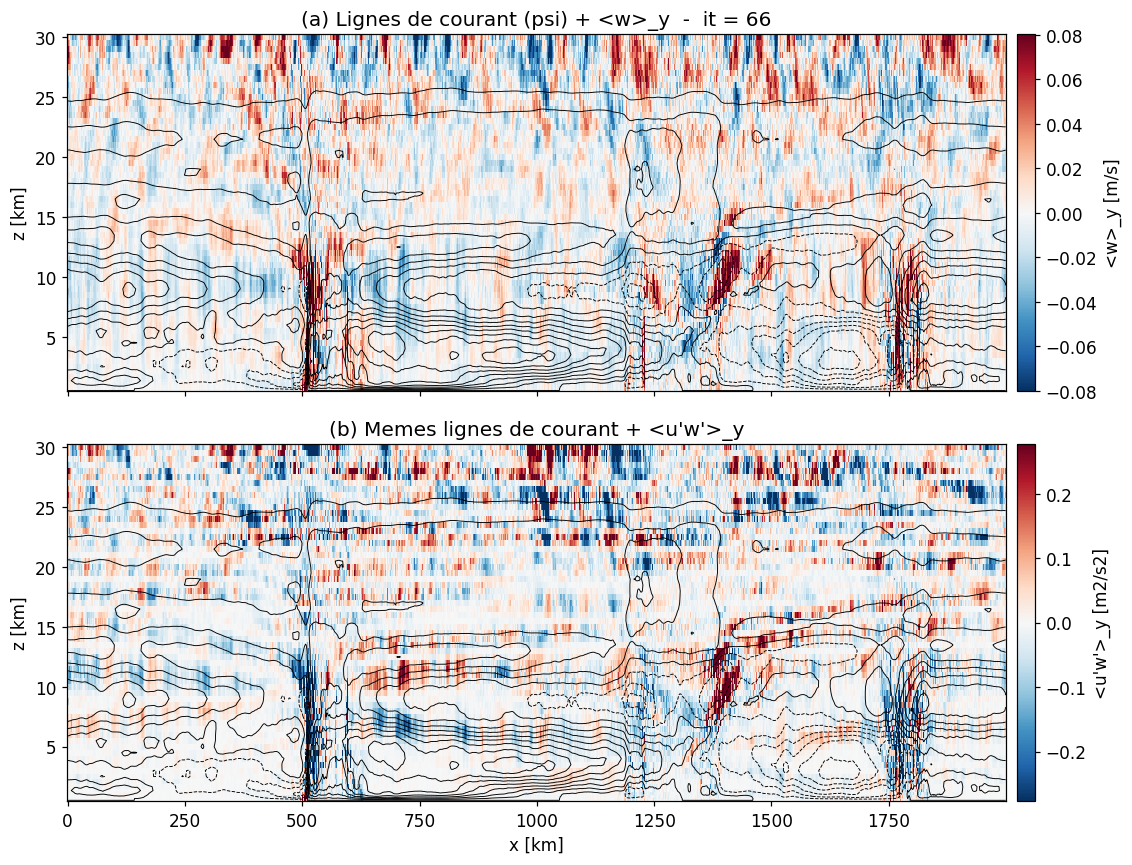

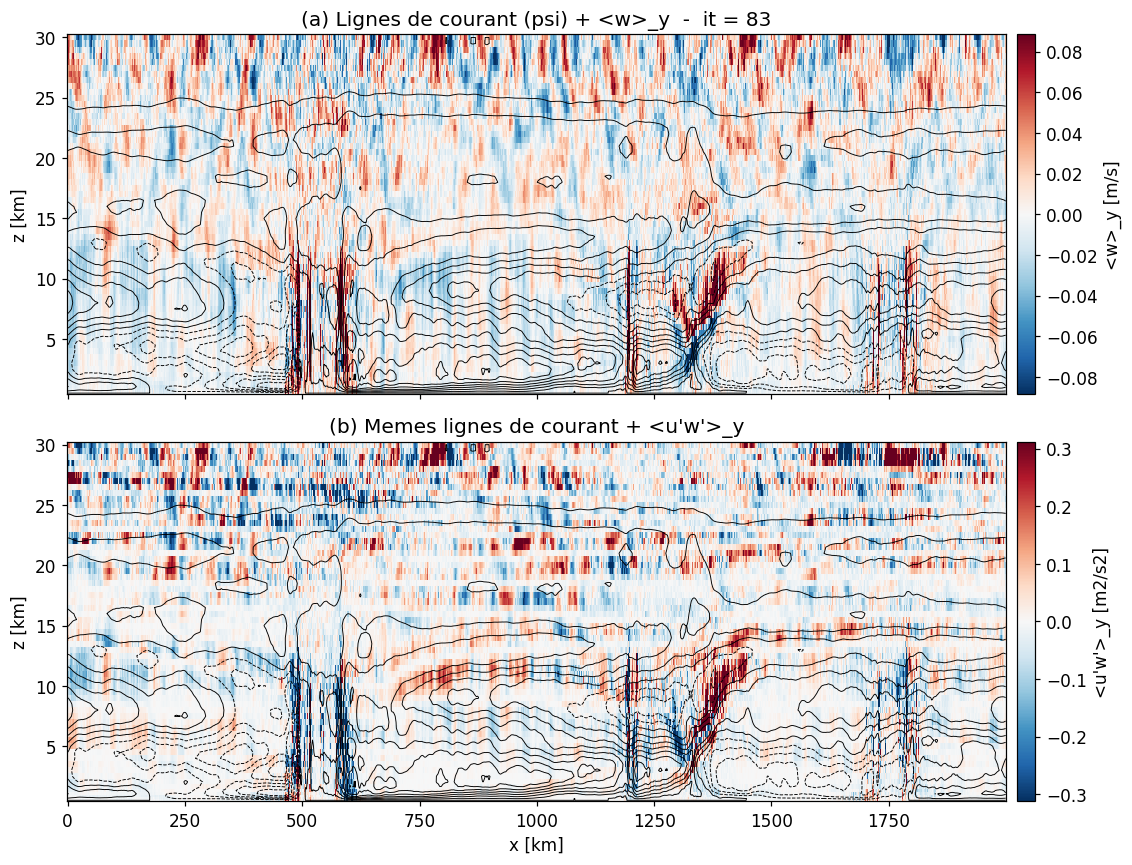

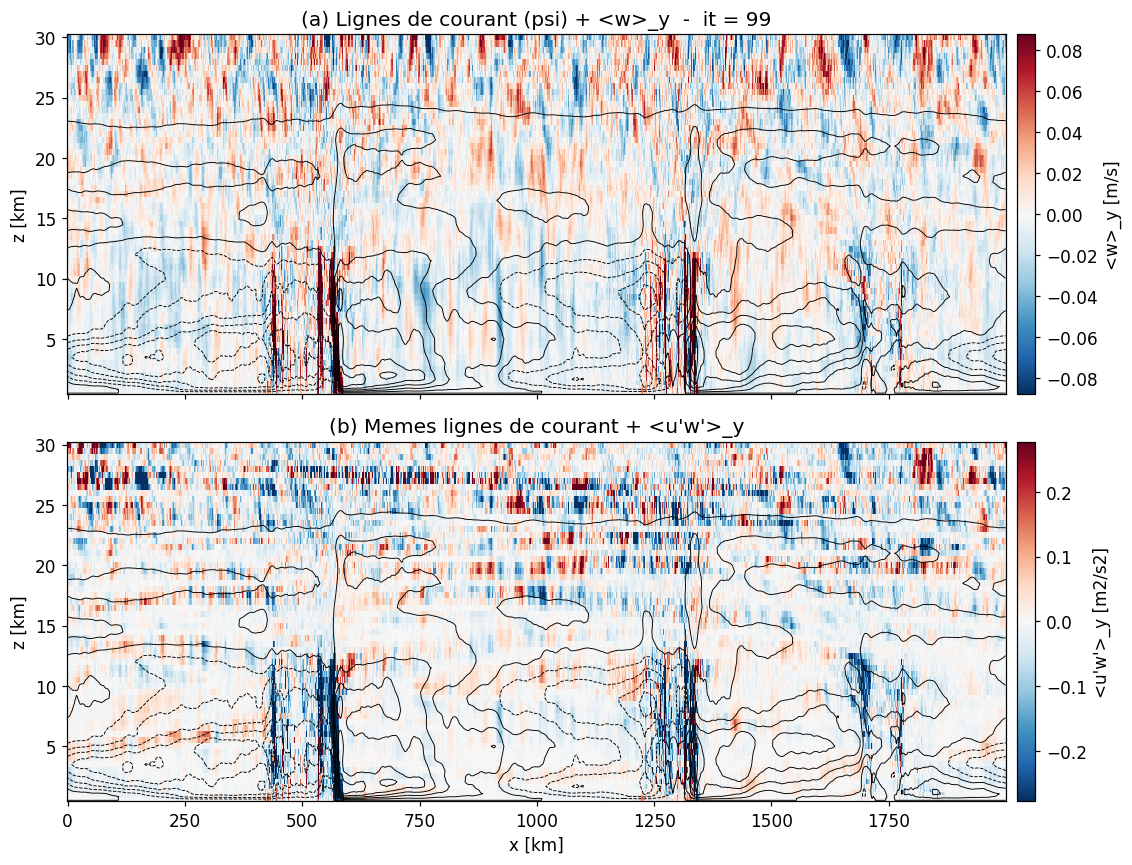

In [68]:
# ======================================================================
#  Coupes (z,x) à des instants t donnés — moyennées sur y SEULEMENT
#  Version autonome : ne dépend que de dim_t, dim_z, dim_x, n_t, n_x,
#  alt, t_stat, n_stat, x, path3d. Recalcule rho0 et tout le reste.
# ======================================================================
from scipy.sparse import diags, kron, identity
from scipy.sparse.linalg import spsolve

ZMIN, ZMAX = 500., 30000.
T_SNAPS = [t_stat, t_stat + n_stat//2, n_t - 1]   # instants à tracer

# --- rho0 sur la grille COMPLETE (au cas où il aurait été tronqué ailleurs) ---
_nz_full = alt.size
rho0_full = np.zeros(_nz_full); _nr = 0
_da = xr.open_dataset(path3d('ta')); _dp = xr.open_dataset(path3d('pa')); _dh = xr.open_dataset(path3d('hus'))
for t0 in range(t_stat, n_t, BLOC):
    t1 = min(t0+BLOC, n_t); sl = {dim_t: slice(t0,t1)}
    T = _da['ta'].isel(sl).values; P = _dp['pa'].isel(sl).values; Q = _dh['hus'].isel(sl).values
    Tv = T*(1.0+Q/EPSILON)/(1.0+Q)
    rho0_full += (P/(Rd*Tv)).mean(axis=(0,2,3))*(t1-t0); _nr += (t1-t0)
    del T,P,Q,Tv; gc.collect()
_da.close(); _dp.close(); _dh.close(); del _da,_dp,_dh; gc.collect()
rho0_full /= _nr

kz = (alt >= ZMIN) & (alt <= ZMAX)        # masque vertical 2-18 km

def coupe_instant(it):
    U_i = np.zeros((_nz_full, n_x)); W_i = np.zeros((_nz_full, n_x)); UP_i = np.zeros((_nz_full, n_x))
    du = xr.open_dataset(path3d('ua')); dw = xr.open_dataset(path3d('wa'))
    for iz in range(_nz_full):
        u_yx = du['ua'].isel({dim_t: it, dim_z: iz}).values
        w_yx = dw['wa'].isel({dim_t: it, dim_z: iz}).values
        u_p = u_yx - u_yx.mean(); w_p = w_yx - w_yx.mean()
        U_i[iz] = u_yx.mean(axis=0); W_i[iz] = w_yx.mean(axis=0)
        UP_i[iz] = (u_p*w_p).mean(axis=0)
        del u_yx, w_yx, u_p, w_p
    du.close(); dw.close(); del du, dw; gc.collect()
    return alt[kz], rho0_full[kz], U_i[kz], W_i[kz], UP_i[kz]

def psi_poisson_periodic(U_i, W_i, x, z_i, rho_i):
    """psi de masse : PÉRIODIQUE en x, DIRICHLET (psi=0) en z (sol/sommet).
    w ne traverse pas les bords haut/bas ; le domaine se referme en x.
    psi ancré en un point (le Laplacien périodique est singulier)."""
    nz, nx = U_i.shape
    dxl = float(x[1]-x[0]); dzl = float(z_i[1]-z_i[0])
    rhoU = rho_i[:, None]*U_i
    rhoW = rho_i[:, None]*W_i

    # --- terme source : dérivée en x PÉRIODIQUE (np.roll fait le wrap) ---
    ddx_rhoW = (np.roll(rhoW, -1, axis=1) - np.roll(rhoW, 1, axis=1)) / (2*dxl)
    ddz_rhoU = np.gradient(rhoU, dzl, axis=0)
    omega = ddx_rhoW - ddz_rhoU

    # --- Lx périodique : toutes les nx colonnes sont inconnues ---
    Lx = diags([1., -2., 1.], [-1, 0, 1], shape=(nx, nx), format='lil')
    Lx[0, nx-1] = 1.0       # le point 0 voit le point nx-1 (wrap gauche)
    Lx[nx-1, 0] = 1.0       # le point nx-1 voit le point 0 (wrap droit)
    Lx = Lx.tocsr() / dxl**2

    # --- Lz Dirichlet : seulement les nz-2 niveaux intérieurs ---
    Lz = diags([1., -2., 1.], [-1, 0, 1], shape=(nz-2, nz-2)).tocsr() / dzl**2

    Ix = identity(nx)
    Iz = identity(nz-2)
    A = (kron(Iz, Lx) + kron(Lz, Ix)).tolil()

    b = omega[1:-1, :].ravel().copy()     # tous les x, niveaux intérieurs en z

    psi = np.zeros((nz, nx))
    psi[1:-1, :] = spsolve(A, b).reshape(nz-2, nx)
    return psi


for it in T_SNAPS:
    z_i, rho_i, U_i, W_i, UP_i = coupe_instant(it)
    psi_i = psi_poisson_periodic(U_i, W_i, x, z_i, rho_i)
    Xkm, Zkm = x/1000, z_i/1000

    fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
    ax = axes[0]
    wmax = np.percentile(np.abs(W_i), 99) + 1e-12
    pc = ax.pcolormesh(Xkm, Zkm, W_i, shading='auto',
                       norm=TwoSlopeNorm(vcenter=0, vmin=-wmax, vmax=wmax), cmap='RdBu_r')
    ax.contour(Xkm, Zkm, psi_i, levels=14, colors='k', linewidths=0.6)
    ax.set_title(f"(a) Lignes de courant (psi) + <w>_y  -  it = {it}")
    ax.set_ylabel('z [km]'); fig.colorbar(pc, ax=ax, label='<w>_y [m/s]', pad=0.01)

    ax = axes[1]
    fmax = np.percentile(np.abs(UP_i), 98) + 1e-12
    pc = ax.pcolormesh(Xkm, Zkm, UP_i, shading='auto',
                       norm=TwoSlopeNorm(vcenter=0, vmin=-fmax, vmax=fmax), cmap='RdBu_r')
    ax.contour(Xkm, Zkm, psi_i, levels=14, colors='k', linewidths=0.6)
    ax.set_title("(b) Memes lignes de courant + <u'w'>_y")
    ax.set_xlabel('x [km]'); ax.set_ylabel('z [km]')
    fig.colorbar(pc, ax=ax, label="<u'w'>_y [m2/s2]", pad=0.01)
    plt.tight_layout(); plt.show()

/tmp/ipykernel_5611/319698632.py:81: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pc = ax.pcolormesh(Xkm, Zkm, W_i, shading='auto',
/tmp/ipykernel_5611/319698632.py:89: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pc = ax.pcolormesh(Xkm, Zkm, UP_i, shading='auto',


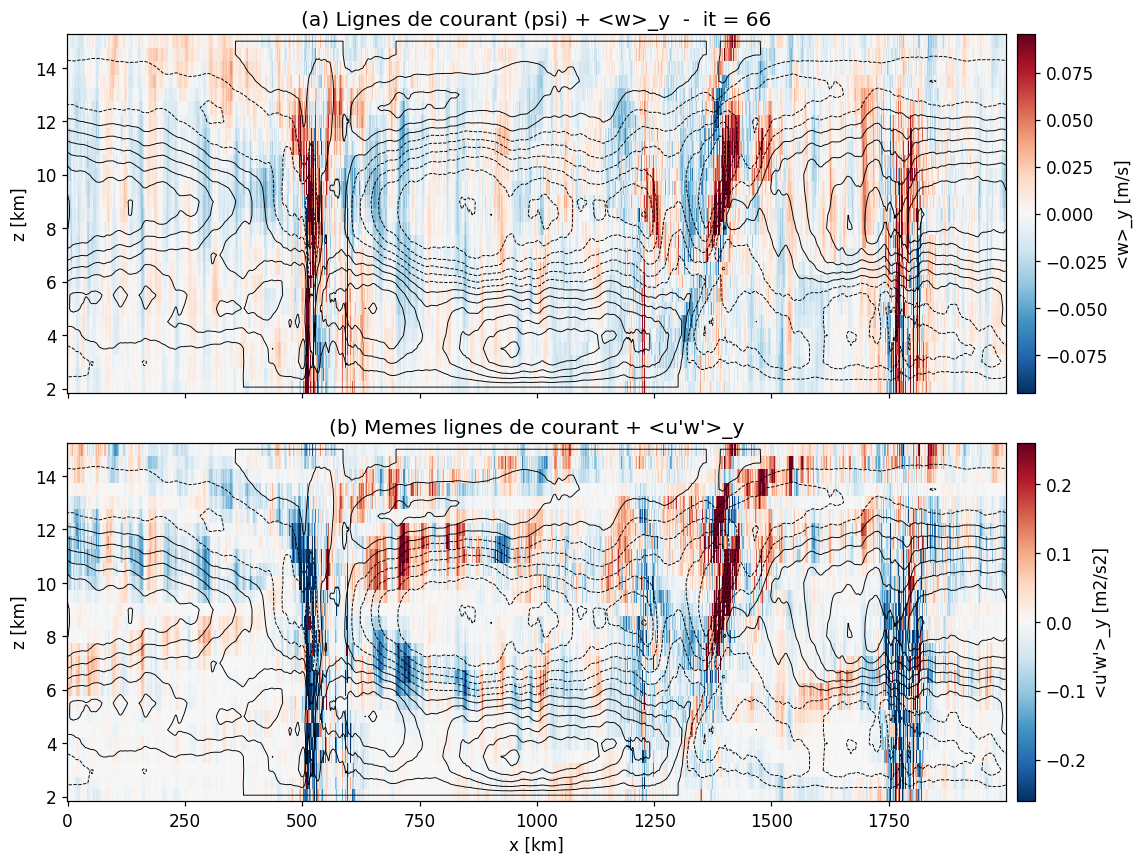

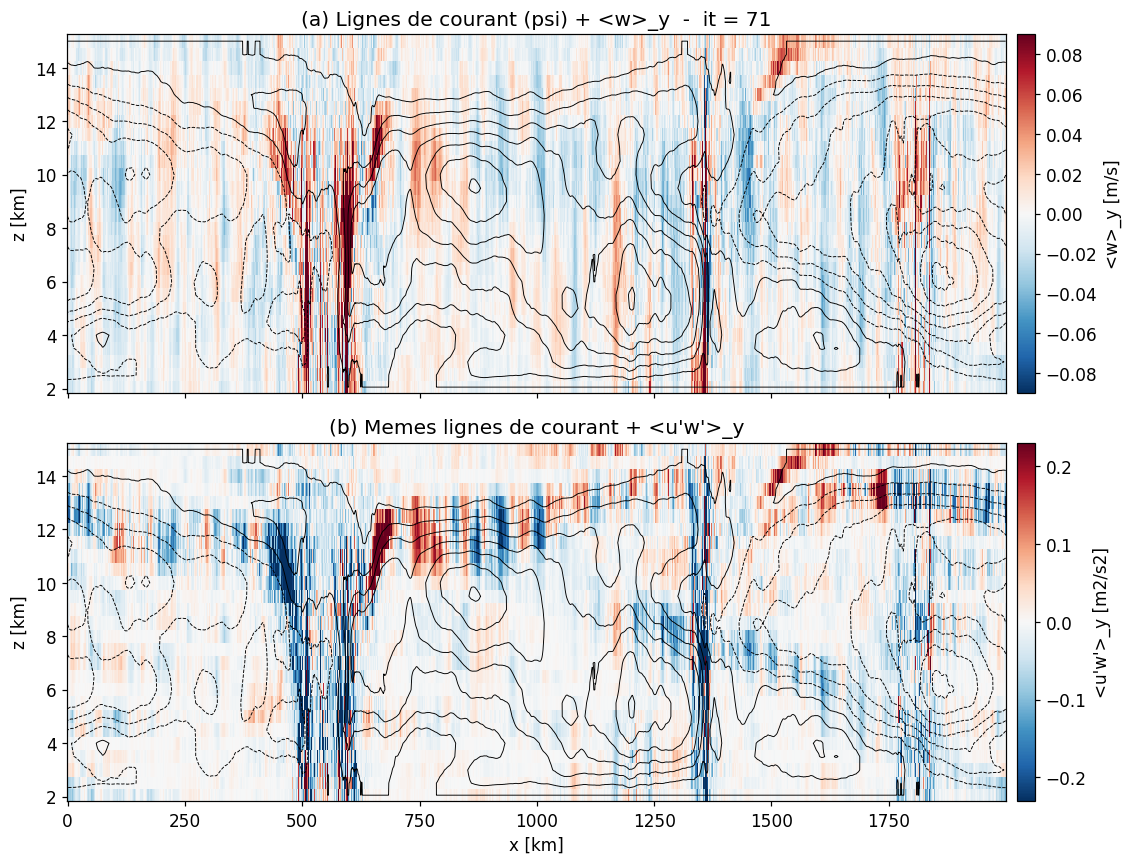

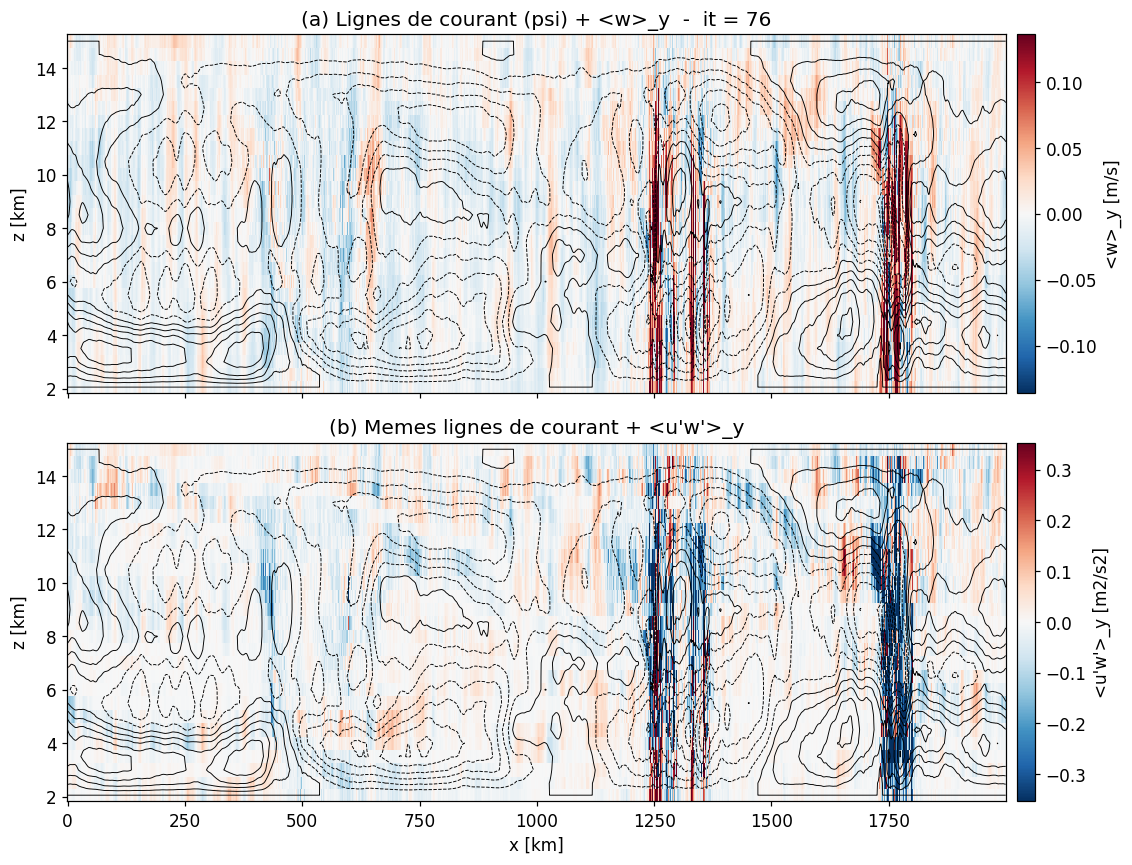

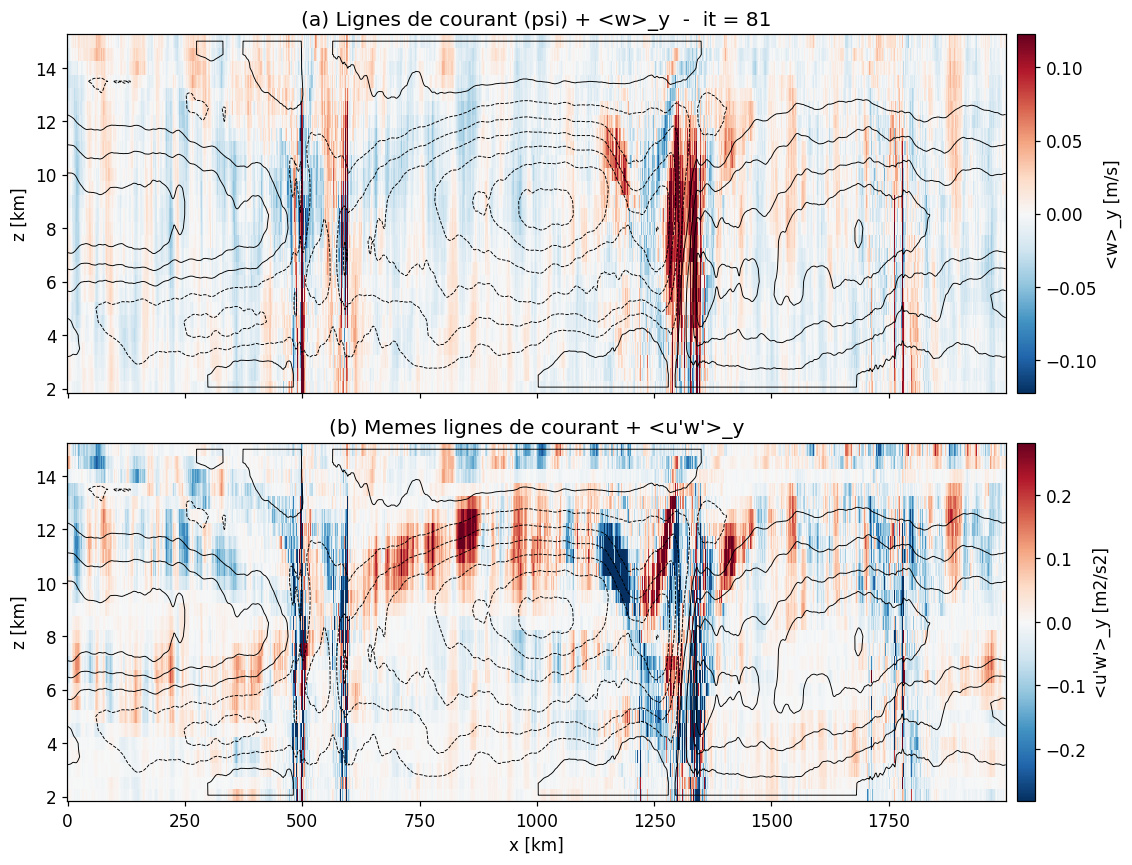

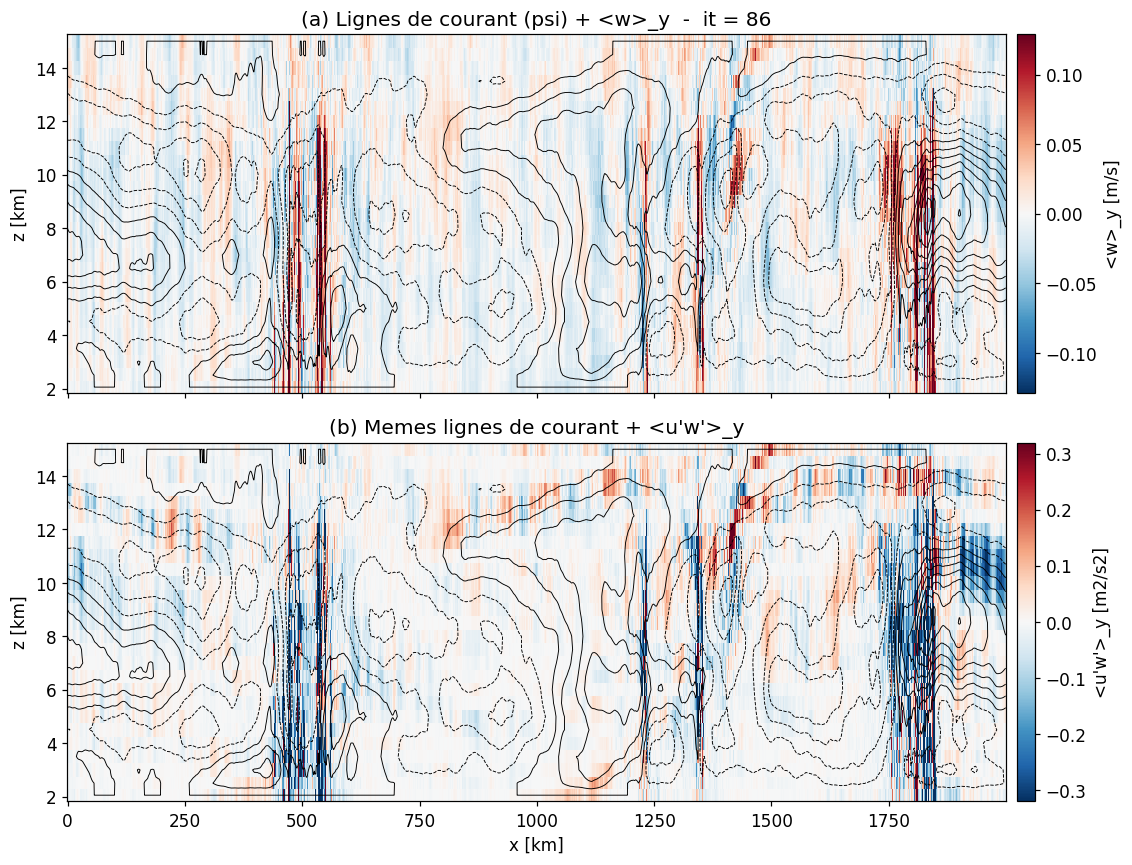

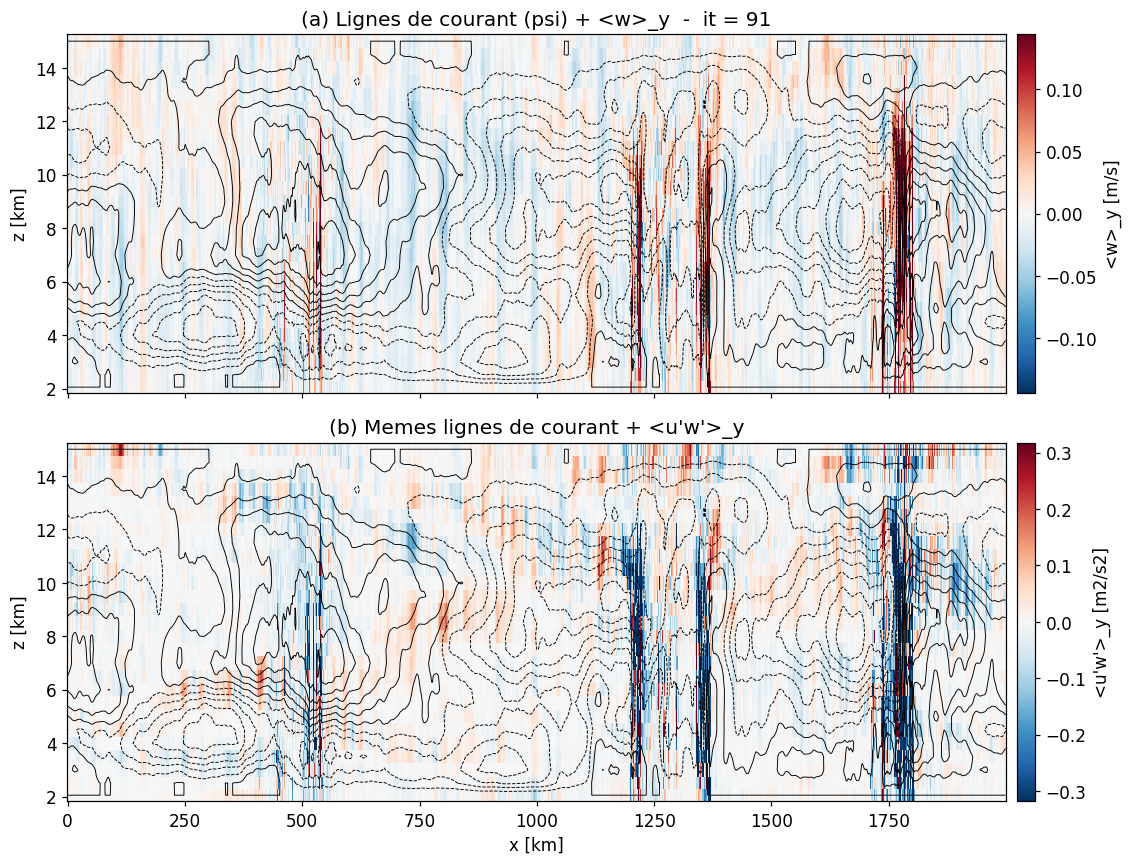

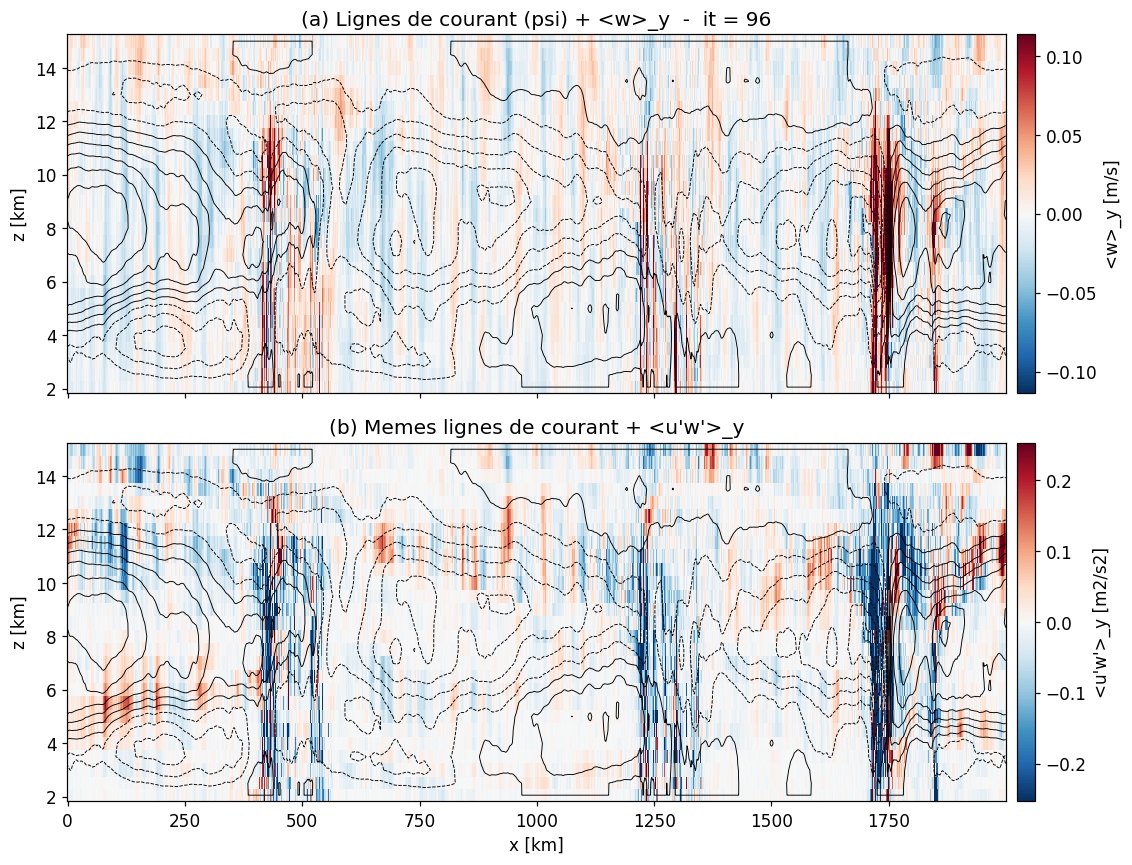

In [69]:
# ======================================================================
#  Coupes (z,x) à des instants t donnés — moyennées sur y SEULEMENT
#  Version autonome : ne dépend que de dim_t, dim_z, dim_x, n_t, n_x,
#  alt, t_stat, n_stat, x, path3d. Recalcule rho0 et tout le reste.
# ======================================================================
from scipy.sparse import diags, kron, identity
from scipy.sparse.linalg import spsolve

ZMIN, ZMAX = 2000., 15000.
T_SNAPS = list(range(t_stat, n_t, 5))   # instants à tracer

# --- rho0 sur la grille COMPLETE (au cas où il aurait été tronqué ailleurs) ---
_nz_full = alt.size
rho0_full = np.zeros(_nz_full); _nr = 0
_da = xr.open_dataset(path3d('ta')); _dp = xr.open_dataset(path3d('pa')); _dh = xr.open_dataset(path3d('hus'))
for t0 in range(t_stat, n_t, BLOC):
    t1 = min(t0+BLOC, n_t); sl = {dim_t: slice(t0,t1)}
    T = _da['ta'].isel(sl).values; P = _dp['pa'].isel(sl).values; Q = _dh['hus'].isel(sl).values
    Tv = T*(1.0+Q/EPSILON)/(1.0+Q)
    rho0_full += (P/(Rd*Tv)).mean(axis=(0,2,3))*(t1-t0); _nr += (t1-t0)
    del T,P,Q,Tv; gc.collect()
_da.close(); _dp.close(); _dh.close(); del _da,_dp,_dh; gc.collect()
rho0_full /= _nr

kz = (alt >= ZMIN) & (alt <= ZMAX)        # masque vertical 2-18 km

def coupe_instant(it):
    U_i = np.zeros((_nz_full, n_x)); W_i = np.zeros((_nz_full, n_x)); UP_i = np.zeros((_nz_full, n_x))
    du = xr.open_dataset(path3d('ua')); dw = xr.open_dataset(path3d('wa'))
    for iz in range(_nz_full):
        u_yx = du['ua'].isel({dim_t: it, dim_z: iz}).values
        w_yx = dw['wa'].isel({dim_t: it, dim_z: iz}).values
        u_p = u_yx - u_yx.mean(); w_p = w_yx - w_yx.mean()
        U_i[iz] = u_yx.mean(axis=0); W_i[iz] = w_yx.mean(axis=0)
        UP_i[iz] = (u_p*w_p).mean(axis=0)
        del u_yx, w_yx, u_p, w_p
    du.close(); dw.close(); del du, dw; gc.collect()
    return alt[kz], rho0_full[kz], U_i[kz], W_i[kz], UP_i[kz]

def psi_poisson_periodic(U_i, W_i, x, z_i, rho_i):
    """psi de masse : PÉRIODIQUE en x, DIRICHLET (psi=0) en z (sol/sommet).
    w ne traverse pas les bords haut/bas ; le domaine se referme en x.
    psi ancré en un point (le Laplacien périodique est singulier)."""
    nz, nx = U_i.shape
    dxl = float(x[1]-x[0]); dzl = float(z_i[1]-z_i[0])
    rhoU = rho_i[:, None]*U_i
    rhoW = rho_i[:, None]*W_i

    # --- terme source : dérivée en x PÉRIODIQUE (np.roll fait le wrap) ---
    ddx_rhoW = (np.roll(rhoW, -1, axis=1) - np.roll(rhoW, 1, axis=1)) / (2*dxl)
    ddz_rhoU = np.gradient(rhoU, dzl, axis=0)
    omega = ddx_rhoW - ddz_rhoU

    # --- Lx périodique : toutes les nx colonnes sont inconnues ---
    Lx = diags([1., -2., 1.], [-1, 0, 1], shape=(nx, nx), format='lil')
    Lx[0, nx-1] = 1.0       # le point 0 voit le point nx-1 (wrap gauche)
    Lx[nx-1, 0] = 1.0       # le point nx-1 voit le point 0 (wrap droit)
    Lx = Lx.tocsr() / dxl**2

    # --- Lz Dirichlet : seulement les nz-2 niveaux intérieurs ---
    Lz = diags([1., -2., 1.], [-1, 0, 1], shape=(nz-2, nz-2)).tocsr() / dzl**2

    Ix = identity(nx)
    Iz = identity(nz-2)
    A = (kron(Iz, Lx) + kron(Lz, Ix)).tolil()

    b = omega[1:-1, :].ravel().copy()     # tous les x, niveaux intérieurs en z

    psi = np.zeros((nz, nx))
    psi[1:-1, :] = spsolve(A, b).reshape(nz-2, nx)
    return psi

for it in T_SNAPS:
    z_i, rho_i, U_i, W_i, UP_i = coupe_instant(it)
    psi_i = psi_poisson_periodic(U_i, W_i, x, z_i, rho_i)
    Xkm, Zkm = x/1000, z_i/1000

    fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
    ax = axes[0]
    wmax = np.percentile(np.abs(W_i), 99) + 1e-12
    pc = ax.pcolormesh(Xkm, Zkm, W_i, shading='auto',
                       norm=TwoSlopeNorm(vcenter=0, vmin=-wmax, vmax=wmax), cmap='RdBu_r')
    ax.contour(Xkm, Zkm, psi_i, levels=14, colors='k', linewidths=0.6)
    ax.set_title(f"(a) Lignes de courant (psi) + <w>_y  -  it = {it}")
    ax.set_ylabel('z [km]'); fig.colorbar(pc, ax=ax, label='<w>_y [m/s]', pad=0.01)

    ax = axes[1]
    fmax = np.percentile(np.abs(UP_i), 98) + 1e-12
    pc = ax.pcolormesh(Xkm, Zkm, UP_i, shading='auto',
                       norm=TwoSlopeNorm(vcenter=0, vmin=-fmax, vmax=fmax), cmap='RdBu_r')
    ax.contour(Xkm, Zkm, psi_i, levels=14, colors='k', linewidths=0.6)
    ax.set_title("(b) Memes lignes de courant + <u'w'>_y")
    ax.set_xlabel('x [km]'); ax.set_ylabel('z [km]')
    fig.colorbar(pc, ax=ax, label="<u'w'>_y [m2/s2]", pad=0.01)
    plt.tight_layout(); plt.show()

/tmp/ipykernel_5611/1595102594.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pc2 = ax2.pcolormesh(Xkm, Zkm, psi_i, shading='auto',


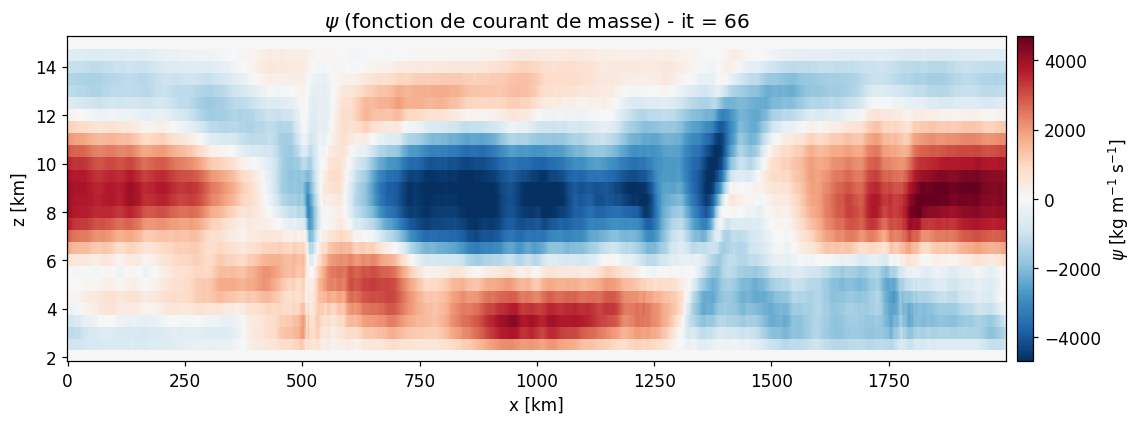

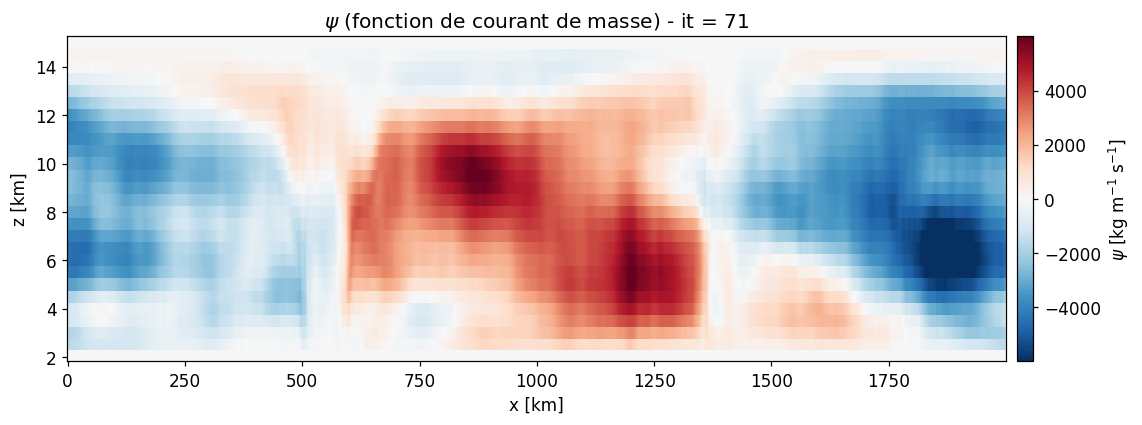

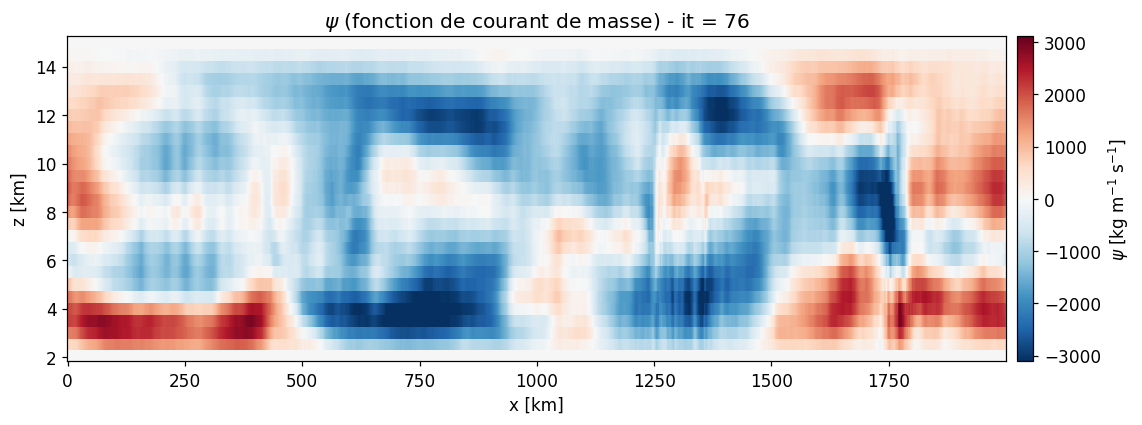

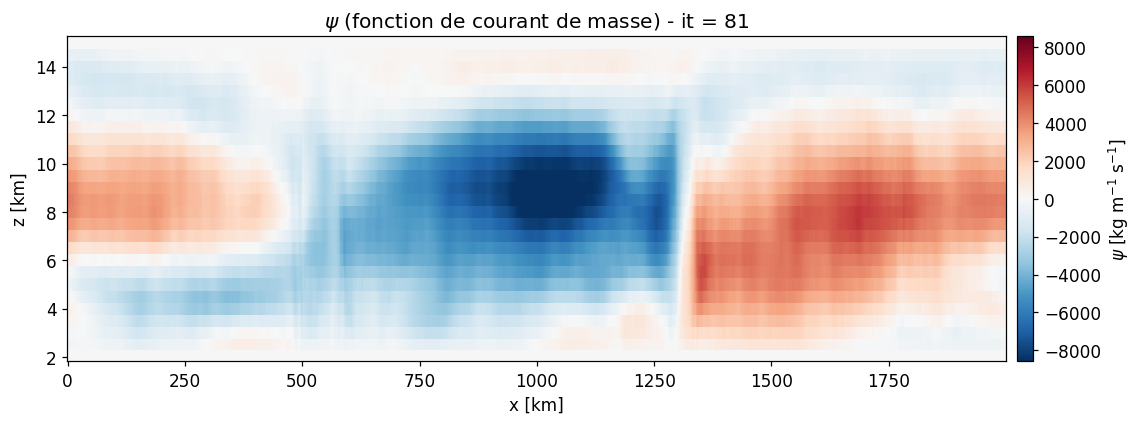

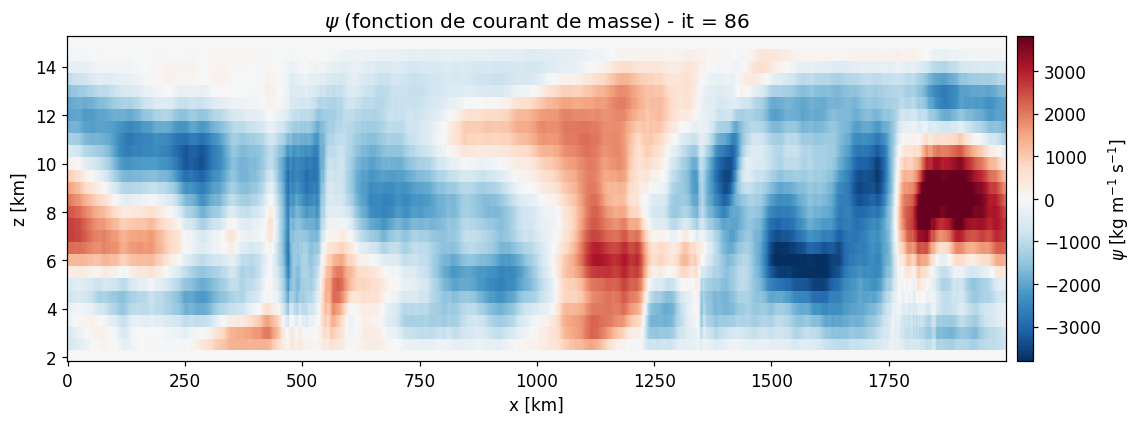

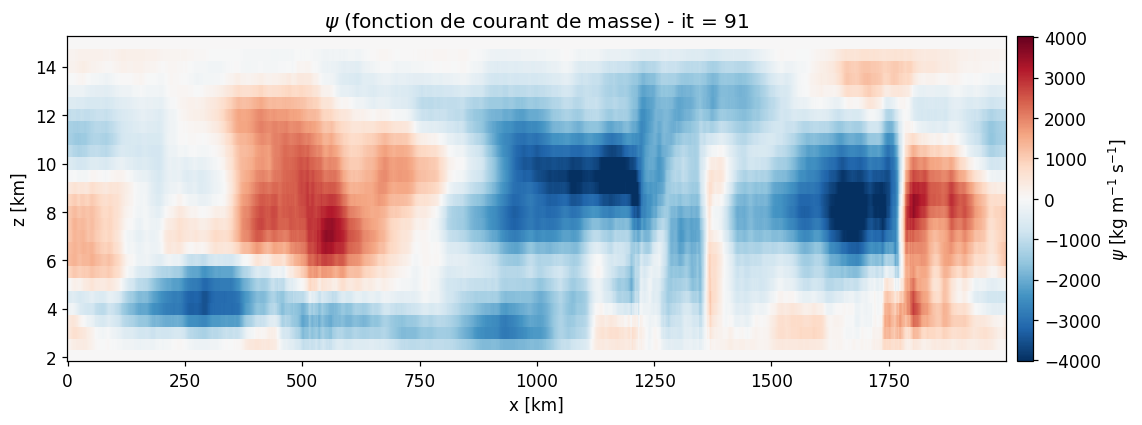

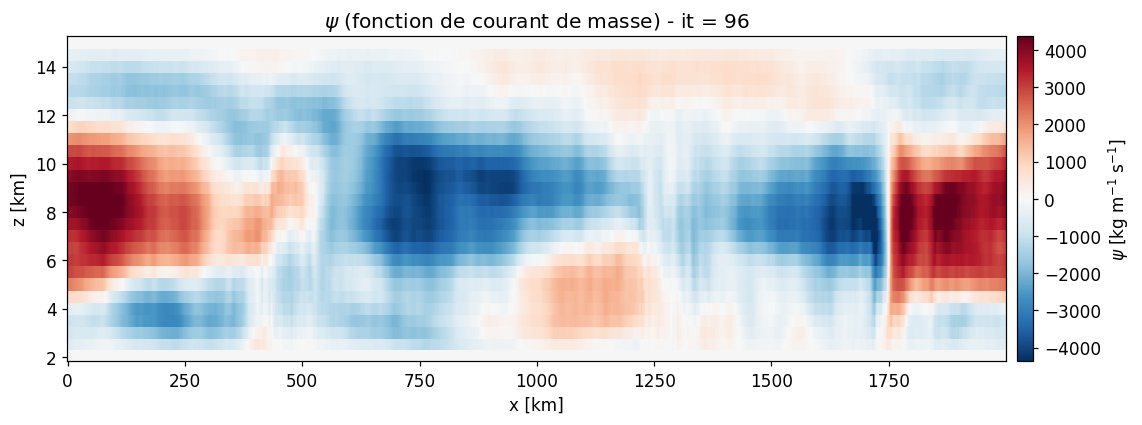

In [63]:
for it in T_SNAPS:
    z_i, rho_i, U_i, W_i, UP_i = coupe_instant(it)
    psi_i = psi_poisson_periodic(U_i, W_i, x, z_i, rho_i)
    Xkm, Zkm = x/1000, z_i/1000

    fig2, ax2 = plt.subplots(figsize=(11, 4))
    pmax = np.percentile(np.abs(psi_i), 99) + 1e-12
    pc2 = ax2.pcolormesh(Xkm, Zkm, psi_i, shading='auto',
                         norm=TwoSlopeNorm(vcenter=0, vmin=-pmax, vmax=pmax),
                         cmap='RdBu_r')
    ax2.set_xlabel('x [km]'); ax2.set_ylabel('z [km]')
    ax2.set_title(f"$\\psi$ (fonction de courant de masse) - it = {it}")
    fig2.colorbar(pc2, ax=ax2, label=r'$\psi$ [kg m$^{-1}$ s$^{-1}$]', pad=0.01)
    plt.tight_layout(); plt.show()

contrôle identité  max|Φ2D − Σ_k(T1_k+T2_k)| = 2.01e-09  (doit être ~1e-18)
poids médian  T1 (organisé x) = 88%   T2 (résidu x) = 48%


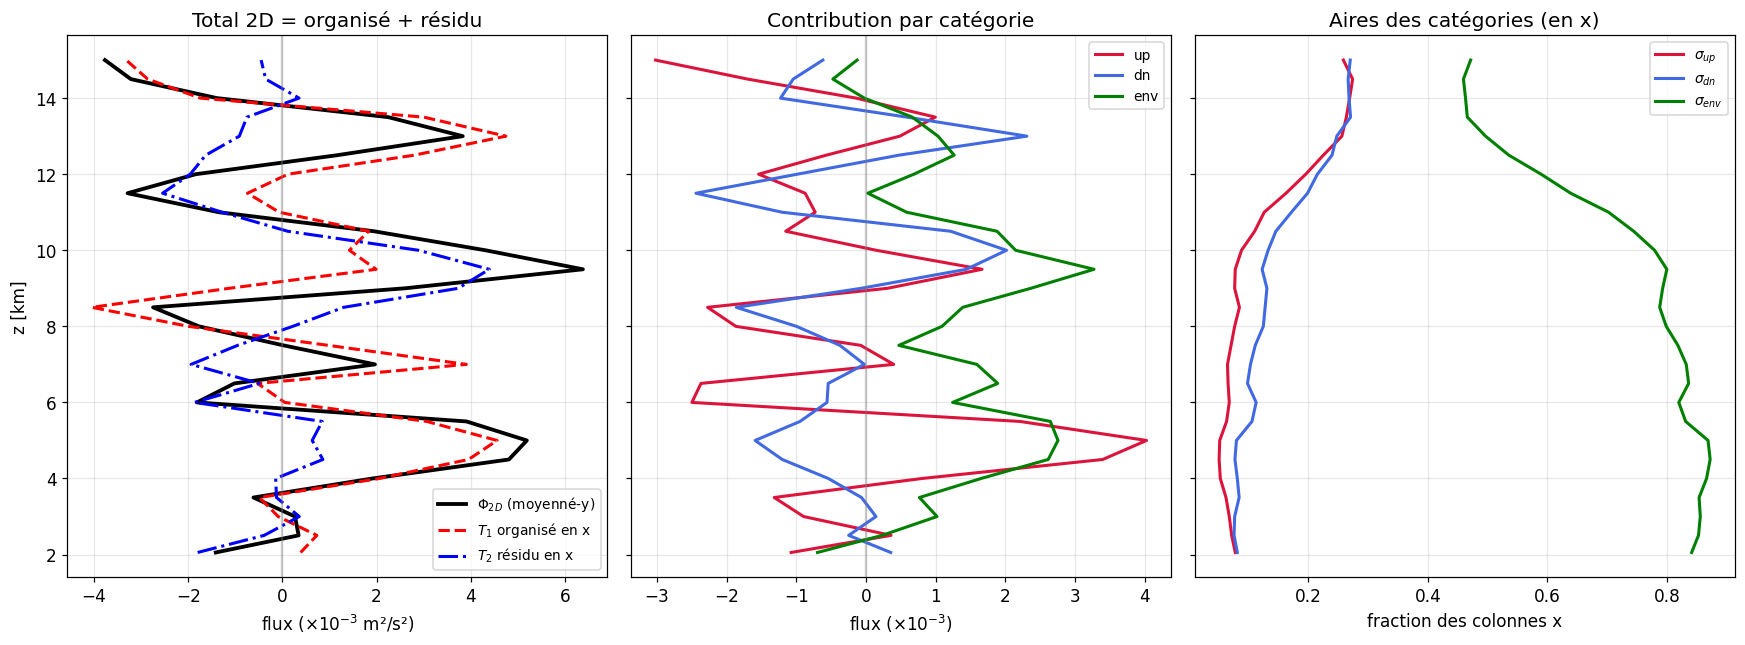

In [64]:
# ======================================================================
#  Décomposition par zones up/dn/env EN 2D (moyenné sur y)
#  À un instant it : pour chaque z, on moyenne sur y -> profils <u>_y(x), <w>_y(x)
#  Puis on classe les COLONNES x en up/dn/env selon <w>_y(x), seuil w_s = C*std_x(<w>_y)
#
#    Phi2D(z) = somme_k [ T1_k(z) + T2_k(z) ]                 (identité exacte)
#    T1_k(z)  = sigma_k * (uc_k - <u>)(wc_k - <w>)            <- organisé en x
#    T2_k(z)  = sigma_k * < (<u>_y - uc_k)(<w>_y - wc_k) >_k  <- résidu en x intra-cat
#  où moyennes/std sont prises SUR LES COLONNES x du profil moyenné-y.
# ======================================================================
ZMIN_D, ZMAX_D = 2000., 15000.
IT_DECOMP = n_t - 1
C_DECOMP  = 0.6
W0_MIN    = 0.001
USE_REG   = False        # True -> ne moyenne que sur les colonnes humides

kz_d   = (alt >= ZMIN_D) & (alt <= ZMAX_D)
iz_lst = np.where(kz_d)[0]
z_D    = alt[kz_d]; nz_D = z_D.size
cats   = ('up', 'dn', 'env')

phi2d = np.zeros(nz_D)
T1    = {k: np.zeros(nz_D) for k in cats}
T2    = {k: np.zeros(nz_D) for k in cats}
sig   = {k: np.zeros(nz_D) for k in cats}

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for j, iz in enumerate(iz_lst):
    u_yx = ds_u['ua'].isel({dim_t: IT_DECOMP, dim_z: iz}).values   # (ny, nx)
    w_yx = ds_w['wa'].isel({dim_t: IT_DECOMP, dim_z: iz}).values

    # --- moyenne sur y -> profils en x (le "nuage" devient les colonnes x) ---
    if USE_REG:
        uy = u_yx[mh].mean(axis=0) if mh.ndim==1 else np.where(mh, u_yx, np.nan)
        # cas simple : mh est un masque (ny,nx) -> moyenne y pondérée par mh
        uy = np.nanmean(np.where(mh, u_yx, np.nan), axis=0)
        wy = np.nanmean(np.where(mh, w_yx, np.nan), axis=0)
    else:
        uy = u_yx.mean(axis=0)        # <u>_y(x)  (nx,)
        wy = w_yx.mean(axis=0)        # <w>_y(x)

    ubar, wbar, Nx = uy.mean(), wy.mean(), uy.size

    # flux Reynolds "2D" : covariance en x des profils moyennés-y
    phi2d[j] = ((uy - ubar) * (wy - wbar)).mean()

    # seuil sur la dispersion EN x de <w>_y
    ws = max(W0_MIN, C_DECOMP * wy.std())
    masks = {'up': wy > ws, 'dn': wy < -ws, 'env': np.abs(wy) <= ws}

    for k in cats:
        m = masks[k]; Nk = m.sum()
        if Nk == 0:
            continue
        sk = Nk / Nx
        uc = uy[m].mean(); wc = wy[m].mean()
        sig[k][j] = sk
        T1[k][j] = sk * (uc - ubar) * (wc - wbar)                       # organisé
        T2[k][j] = sk * ((uy[m] - uc) * (wy[m] - wc)).mean()            # résidu en x

    del u_yx, w_yx; gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

# --- totaux + contrôle d'identité ---
T1tot = sum(T1[k] for k in cats)
T2tot = sum(T2[k] for k in cats)
err = np.abs(phi2d - (T1tot + T2tot)).max()
print(f"contrôle identité  max|Φ2D − Σ_k(T1_k+T2_k)| = {err:.2e}  (doit être ~1e-18)")

frac_T1 = np.median(np.abs(T1tot) / (np.abs(phi2d) + 1e-30))
frac_T2 = np.median(np.abs(T2tot) / (np.abs(phi2d) + 1e-30))
print(f"poids médian  T1 (organisé x) = {frac_T1:.0%}   T2 (résidu x) = {frac_T2:.0%}")

# ======================================================================
#  FIGURE
# ======================================================================
Zkm = z_D / 1000; sc = 1e3
col = {'up': 'crimson', 'dn': 'royalblue', 'env': 'green'}
fig, ax = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

ax[0].plot(phi2d*sc, Zkm, 'k',   lw=2.5, label=r"$\Phi_{2D}$ (moyenné-y)")
ax[0].plot(T1tot*sc, Zkm, 'r--', lw=2,   label=r'$T_1$ organisé en x')
ax[0].plot(T2tot*sc, Zkm, 'b-.', lw=2,   label=r'$T_2$ résidu en x')
ax[0].axvline(0, color='grey', alpha=.4)
ax[0].set_xlabel(r'flux ($\times10^{-3}$ m²/s²)'); ax[0].set_ylabel('z [km]')
ax[0].set_title('Total 2D = organisé + résidu'); ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)

for k in cats:
    ax[1].plot((T1[k] + T2[k])*sc, Zkm, color=col[k], lw=2, label=k)
ax[1].axvline(0, color='grey', alpha=.4)
ax[1].set_xlabel(r'flux ($\times10^{-3}$)'); ax[1].set_title('Contribution par catégorie')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)

for k in cats:
    ax[2].plot(sig[k], Zkm, color=col[k], lw=2, label=fr'$\sigma_{{{k}}}$')
ax[2].set_xlabel('fraction des colonnes x'); ax[2].set_title('Aires des catégories (en x)')
ax[2].legend(fontsize=9); ax[2].grid(alpha=.3)

plt.tight_layout(); plt.show()

In [65]:
# ======================================================================
#  Balayage de C : on cherche le C dont T1_tot (rouge) colle le mieux à Phi2D (noir)
#  Phi2D et T1_tot sont tous deux des covariances (m²/s²) -> comparaison directe.
# ======================================================================
ZMIN_D, ZMAX_D = 2000., 15000.
IT_DECOMP = n_t - 1
W0_MIN    = 0.001
Cs = np.array([0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0,
               1.2, 1.5, 1.8, 2.0, 2.5, 3.0, 4.0, 5.0, 7.0, 10.0])

kz_d   = (alt >= ZMIN_D) & (alt <= ZMAX_D)
iz_lst = np.where(kz_d)[0]
z_D    = alt[kz_d]; nz_D = z_D.size
cats   = ('up', 'dn', 'env')

phi2d  = np.zeros(nz_D)
T1tot  = {C: np.zeros(nz_D) for C in Cs}      # le "rouge" pour chaque C

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for j, iz in enumerate(iz_lst):
    u_yx = ds_u['ua'].isel({dim_t: IT_DECOMP, dim_z: iz}).values
    w_yx = ds_w['wa'].isel({dim_t: IT_DECOMP, dim_z: iz}).values
    uy = u_yx.mean(axis=0); wy = w_yx.mean(axis=0)
    ubar, wbar, Nx = uy.mean(), wy.mean(), uy.size

    phi2d[j] = ((uy - ubar) * (wy - wbar)).mean()     # noir

    sw = wy.std()
    for C in Cs:
        ws = max(W0_MIN, C * sw)
        masks = {'up': wy > ws, 'dn': wy < -ws, 'env': np.abs(wy) <= ws}
        acc = 0.0
        for m in masks.values():
            Nk = m.sum()
            if Nk == 0: continue
            sk = Nk / Nx
            uc = uy[m].mean(); wc = wy[m].mean()
            acc += sk * (uc - ubar) * (wc - wbar)     # T1 par catégorie
        T1tot[C][j] = acc
    del u_yx, w_yx; gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

# --- NSE de chaque C : T1tot vs phi2d ---
def nse_loc(truth, pred):
    ok = np.isfinite(truth) & np.isfinite(pred)
    return 1 - np.nansum((truth[ok]-pred[ok])**2) / np.nansum((truth[ok]-np.nanmean(truth[ok]))**2)

scores = {C: nse_loc(phi2d, T1tot[C]) for C in Cs}
C_star = max(scores, key=scores.get)
print(f"{'C':>6} | {'NSE(T1 vs Phi2D)':>18}")
print('-'*28)
for C in Cs: print(f"{C:6.2f} | {scores[C]:+18.3f}")
print(f"\n>> C* = {C_star}   (NSE = {scores[C_star]:+.3f})")


     C |   NSE(T1 vs Phi2D)
----------------------------
  0.05 |             +0.664
  0.10 |             +0.593
  0.15 |             +0.517
  0.20 |             +0.467
  0.30 |             +0.353
  0.40 |             +0.435
  0.50 |             +0.586
  0.60 |             +0.655
  0.80 |             +0.476
  1.00 |             +0.252
  1.20 |             +0.170
  1.50 |             +0.104
  1.80 |             +0.108
  2.00 |             +0.130
  2.50 |             +0.283
  3.00 |             +0.322
  4.00 |             +0.205
  5.00 |             +0.155
  7.00 |             +0.238
 10.00 |             +0.034

>> C* = 0.05   (NSE = +0.664)


nx=2000  dx=1.00 km  domaine=2000 km
[Parseval]  max|sum_λ Co - T2|       = 3.42e-06  (~1e-18)
[cohérence] max|T2_spectre - T2[up]| = 1.30e-10  (~1e-18)
niveau |T2_up| max : z = 7.0 km   T2 = -2.87e-03


/tmp/ipykernel_5611/2233533064.py:79: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pc0 = ax.pcolormesh(lam_km[1:], z_D/1000, A, shading='auto',


TypeError: 'AxesSubplot' object is not subscriptable

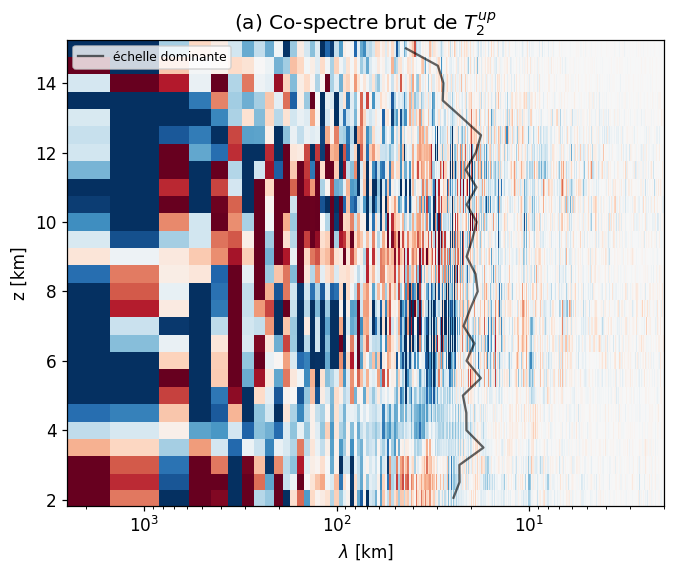

In [66]:
# ======================================================================
#  Où vit la covariance within T2 ?  Décomposition Fourier + ondelettes
#  Part du T2[CAT] calculé dans le bloc up/dn/env (même bande, même instant).
#    T2_k/.. = <u'' w''>_x = somme_λ Co(λ)   (Parseval, contrôlé)
#  (a) co-spectre Fourier  Co(λ,z)   -> à quelle échelle
#  (b) co-scalogramme Morlet (x,λ)   -> à quelle échelle ET où (niveau |T2| max)
#  (c) profil T2(z) + échelle dominante par niveau  -> lien spectre <-> physique
# ======================================================================
CAT = 'up'                         # catégorie dont on spectralise le T2

nx  = x.size
dx  = float(x[1] - x[0])           # pas horizontal [m]
print(f"nx={nx}  dx={dx/1000:.2f} km  domaine={nx*dx/1000:.0f} km")

# --- garde-fou : T2 doit être sur la même bande que ce bloc ---
assert T2[CAT].shape[0] == nz_D, (
    f"T2[{CAT}] a {T2[CAT].shape[0]} niveaux, bande={nz_D} -> "
    "relance le bloc up/dn/env avec la MÊME bande avant celui-ci.")

# --- axes spectraux Fourier ---
kx     = np.fft.rfftfreq(nx, d=dx) * 2*np.pi          # nombre d'onde [rad/m]
lam_km = (2*np.pi / np.maximum(kx, 1e-12)) / 1000     # longueur d'onde [km]

# --- conteneurs ---
Co_T2   = np.zeros((nz_D, kx.size))   # co-spectre par niveau
T2_chk  = np.zeros(nz_D)              # T2 reconstruit (contrôle)
upp_all = np.zeros((nz_D, nx))        # u''(x) (0 hors catégorie) pour ondelettes
wpp_all = np.zeros((nz_D, nx))

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for j, iz in enumerate(iz_lst):
    u_yx = ds_u['ua'].isel({dim_t: IT_DECOMP, dim_z: iz}).values
    w_yx = ds_w['wa'].isel({dim_t: IT_DECOMP, dim_z: iz}).values
    uy = u_yx.mean(axis=0); wy = w_yx.mean(axis=0)      # <u>_y(x), <w>_y(x)

    ws = max(W0_MIN, C_DECOMP * wy.std())
    masks = {'up': wy > ws, 'dn': wy < -ws, 'env': np.abs(wy) <= ws}
    m = masks[CAT]

    # anomalies intra-catégorie, définies sur TOUT x (0 hors cat)
    upp = np.zeros(nx); wpp = np.zeros(nx)
    if m.any():
        upp[m] = uy[m] - uy[m].mean()
        wpp[m] = wy[m] - wy[m].mean()
    upp_all[j] = upp; wpp_all[j] = wpp

    T2_chk[j] = (upp * wpp).mean()        # == T2[CAT][j]

    Fu = np.fft.rfft(upp); Fw = np.fft.rfft(wpp)
    co = np.real(Fu * np.conj(Fw)) / nx**2
    co[1:] *= 2                            # repli fréquences négatives
    Co_T2[j] = co
    del u_yx, w_yx; gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

# --- contrôles ---
err_p = np.abs(Co_T2.sum(axis=1) - T2_chk).max()
err_c = np.abs(T2_chk - T2[CAT]).max()
print(f"[Parseval]  max|sum_λ Co - T2|       = {err_p:.2e}  (~1e-18)")
print(f"[cohérence] max|T2_spectre - T2[{CAT}]| = {err_c:.2e}  (~1e-18)")

k_max = int(np.argmax(np.abs(T2_chk)))
print(f"niveau |T2_{CAT}| max : z = {z_D[k_max]/1000:.1f} km   T2 = {T2_chk[k_max]:.2e}")

# --- échelle dominante par niveau (barycentre |Co| en log-λ, hors k=0) ---
lam_dom = np.zeros(nz_D)
for j in range(nz_D):
    w_ = np.abs(Co_T2[j, 1:])
    lam_dom[j] = np.exp(np.sum(w_*np.log(lam_km[1:])) / (w_.sum()+1e-30)) if w_.sum()>0 else np.nan


# ======================================================================
#  FIGURE  (a) co-spectre  
# ======================================================================
fig, ax = plt.subplots(figsize=(7, 5.5))

A  = Co_T2[:, 1:]                              # <-- plus de kx multiplié
mA = np.percentile(np.abs(A), 99) + 1e-30
pc0 = ax.pcolormesh(lam_km[1:], z_D/1000, A, shading='auto',
                       norm=TwoSlopeNorm(vcenter=0, vmin=-mA, vmax=mA), cmap='RdBu_r')
ax.plot(lam_dom, z_D/1000, 'k-', lw=1.5, alpha=.6, label='échelle dominante')
ax.set_xscale('log'); ax.invert_xaxis()
ax.set_xlabel(r'$\lambda$ [km]'); ax.set_ylabel('z [km]')
ax.set_title(fr'(a) Co-spectre brut de $T_2^{{{CAT}}}$')
ax.legend(fontsize=8, loc='upper left')
fig.colorbar(pc0, ax=ax[0], label=r'$\mathrm{Co}$', pad=0.01)   # label sans le k

plt.tight_layout(); plt.show()

nx=2000  dx=1.00 km  domaine=2000 km  | pondération=k
[Parseval]  max|sum_λ Co - T2|       = 8.67e-19
[cohérence] max|T2_spectre - T2[up]| = 1.30e-10
niveau |T2_up| max : z = 7.0 km


/tmp/ipykernel_5611/4197420028.py:89: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  pc0 = ax.pcolormesh(lam_km[1:], z_D/1000, A_spec, shading='auto',


TypeError: 'AxesSubplot' object is not subscriptable

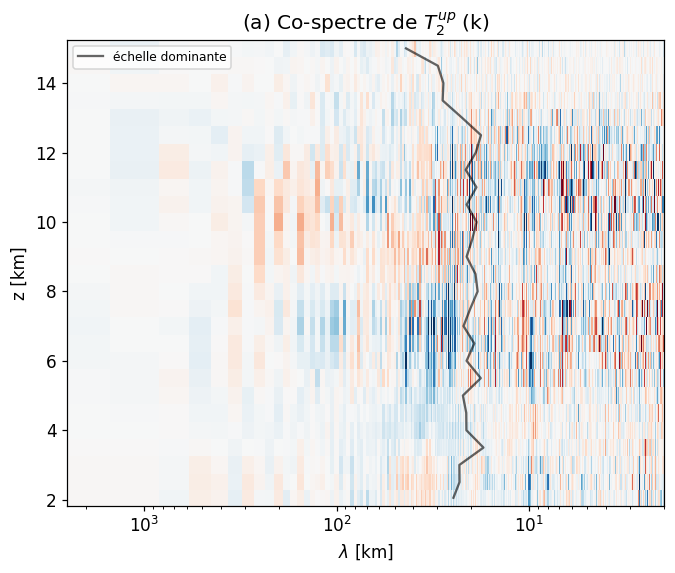

In [67]:
# ======================================================================
#  Où vit la covariance within T2 ? — Fourier + ondelettes, MÊME pondération
#    WEIGHTING = 'k'    -> area-preserving (k·Co) : contribution par décade log
#    WEIGHTING = 'brut' -> Co brut : amplitude absolue (grandes échelles ressortent)
#  Les DEUX panneaux (a) et (b) utilisent la même convention -> cohérents.
# ======================================================================
CAT       = 'up'
WEIGHTING = 'k'                    # 'k' (area-preserving) ou 'brut'

nx  = x.size
dx  = float(x[1] - x[0])
print(f"nx={nx}  dx={dx/1000:.2f} km  domaine={nx*dx/1000:.0f} km  | pondération={WEIGHTING}")

assert T2[CAT].shape[0] == nz_D, (
    f"T2[{CAT}] a {T2[CAT].shape[0]} niveaux, bande={nz_D} -> relance le bloc up/dn/env.")

# --- axes spectraux Fourier ---
kx     = np.fft.rfftfreq(nx, d=dx) * 2*np.pi
lam_km = (2*np.pi / np.maximum(kx, 1e-12)) / 1000

Co_T2   = np.zeros((nz_D, kx.size))
T2_chk  = np.zeros(nz_D)
upp_all = np.zeros((nz_D, nx))
wpp_all = np.zeros((nz_D, nx))

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for j, iz in enumerate(iz_lst):
    u_yx = ds_u['ua'].isel({dim_t: IT_DECOMP, dim_z: iz}).values
    w_yx = ds_w['wa'].isel({dim_t: IT_DECOMP, dim_z: iz}).values
    uy = u_yx.mean(axis=0); wy = w_yx.mean(axis=0)

    ws = max(W0_MIN, C_DECOMP * wy.std())
    masks = {'up': wy > ws, 'dn': wy < -ws, 'env': np.abs(wy) <= ws}
    m = masks[CAT]

    upp = np.zeros(nx); wpp = np.zeros(nx)
    if m.any():
        upp[m] = uy[m] - uy[m].mean()
        wpp[m] = wy[m] - wy[m].mean()
    upp_all[j] = upp; wpp_all[j] = wpp

    T2_chk[j] = (upp * wpp).mean()

    Fu = np.fft.rfft(upp); Fw = np.fft.rfft(wpp)
    co = np.real(Fu * np.conj(Fw)) / nx**2
    if nx % 2 == 0:               # normalisation Nyquist correcte
        co[1:-1] *= 2
    else:
        co[1:]   *= 2
    Co_T2[j] = co
    del u_yx, w_yx; gc.collect()
ds_u.close(); ds_w.close(); del ds_u, ds_w; gc.collect()

# --- contrôles ---
err_p = np.abs(Co_T2.sum(axis=1) - T2_chk).max()
err_c = np.abs(T2_chk - T2[CAT]).max()
print(f"[Parseval]  max|sum_λ Co - T2|       = {err_p:.2e}")
print(f"[cohérence] max|T2_spectre - T2[{CAT}]| = {err_c:.2e}")

k_max = int(np.argmax(np.abs(T2_chk)))
print(f"niveau |T2_{CAT}| max : z = {z_D[k_max]/1000:.1f} km")

# --- échelle dominante (barycentre |Co| en log-λ, inchangée par la pondération) ---
lam_dom = np.zeros(nz_D)
for j in range(nz_D):
    w_ = np.abs(Co_T2[j, 1:])
    lam_dom[j] = np.exp(np.sum(w_*np.log(lam_km[1:])) / (w_.sum()+1e-30)) if w_.sum()>0 else np.nan

# ======================================================================
#  Application de la pondération choisie aux DEUX panneaux
# ======================================================================
if WEIGHTING == 'k':
    A_spec  = kx[None, 1:] * Co_T2[:, 1:]          # k·Co  (Fourier)
    k_scale = 2*np.pi / lam_w[:, None]             # k de chaque échelle ondelette
    A_scal  = co_xz * k_scale                      # k·Co  (ondelettes)
    lab     = r'$k\,\mathrm{Co}$'
else:  # 'brut'
    A_spec  = Co_T2[:, 1:]
    A_scal  = co_xz
    lab     = r'$\mathrm{Co}$'

# ======================================================================
#  FIGURE
# ======================================================================
fig, ax = plt.subplots(figsize=(7, 5.5))

# (a) co-spectre Fourier
mA = np.percentile(np.abs(A_spec), 99) + 1e-30
pc0 = ax.pcolormesh(lam_km[1:], z_D/1000, A_spec, shading='auto',
                       norm=TwoSlopeNorm(vcenter=0, vmin=-mA, vmax=mA), cmap='RdBu_r')
ax.plot(lam_dom, z_D/1000, 'k-', lw=1.5, alpha=.6, label='échelle dominante')
ax.set_xscale('log'); ax.invert_xaxis()
ax.set_xlabel(r'$\lambda$ [km]'); ax.set_ylabel('z [km]')
ax.set_title(fr'(a) Co-spectre de $T_2^{{{CAT}}}$ ({WEIGHTING})')
ax.legend(fontsize=8, loc='upper left')
fig.colorbar(pc0, ax=ax[0], label=lab, pad=0.01)

plt.tight_layout(); plt.show()